In [1]:
import numpy as np
from scipy.integrate import solve_ivp, dblquad
from numba import jit

# Constants used in the model
w_0 = 5  # Initial beam width
n_0 = 1.000277  # Refractive index at reference temperature
z_w = 50  # Reference propagation distance
alpha = 0.002  # Attenuation coefficient
dndT = -7.7 * 10**(-4) / 770 * 0.002  # dn/dT, change in refractive index with temperature (from compensatedLaser.pdf)
gamma = 0.5  # Non-linear coefficient
n = n_0  # Current refractive index, initially set to n_0
xi = 1  # Scaling factor
rho = 1.225  # Air density (kg/m^3)
c_rho = 1005  # Specific heat capacity at constant pressure (J/kg·K)
kappa = 0.025  # Thermal conductivity (W/m·K)
alpha_loss = 0.01  # Loss factor

# Initial conditions for the beam propagation
C_0 = 100  # Initial beam power/amplitude
W_x_0 = W_y_0 = (w_0 * np.sqrt(n_0 * alpha)) / (np.sqrt(w_0**4 + (0-z_w)**2))  # Initial beam widths in x and y directions
T_x_0 = T_y_0 = 0  # Initial tilt angles in x and y directions
X_0 = Y_0 = 0  # Initial positions in x and y directions (of the beam's centers)
F_x_0 = F_y_0 = (-0.5 * n_0 * alpha * (0-z_w)) / (w_0**4 + (0-z_w)**2)  # Initial curvature/focusing parameters in x and y directions
P_0 = np.arctan(z_w / w_0**2)  # Initial phase/piston

# Define the grid for the beam in the transverse plane and heat/refraction profile plane
resolution = 10 # How detailed we want the thermal profile to be. Defines a grid with n*n points
x_cor = np.linspace(-10, 10, resolution)
y_cor = np.linspace(-10, 10, resolution)
x_grid, y_grid = np.meshgrid(x_cor, y_cor)

# Auxiliary functions for heat equation calculation
def f(x_prime, y_prime, x, y):
    """Calculates the logarithmic part of the integrand in the heat equation."""
    return 0.5 * np.log((x - x_prime)**2 + (y - y_prime)**2)

def g(x_prime, y_prime, X, Y, W_x, W_y):
    """Calculates the Gaussian part of the integrand in the heat equation."""
    return np.exp(-W_x**2 * (x_prime - X)**2) * np.exp(-W_y**2 * (y_prime - Y)**2)

@jit
def integrand(x_prime, y_prime, x, y, X, Y, W_x, W_y):
    """Combines the logarithmic and Gaussian parts to form the complete integrand."""
    return f(x_prime, y_prime, x, y) * g(x_prime, y_prime, X, Y, W_x, W_y)

@jit
def solve_heat_equation(x, y, X, Y, W_x, W_y):
    """Solves the heat equation by integrating the specified integrand over a small area around (X, Y)."""
    result, _ = dblquad(integrand, X-1, X+1, Y-1, Y+1, args=(x, y, X, Y, W_x, W_y))
    return result

@jit
def heat_profile(system, x_grid, y_grid, dndT, resolution):
    """Calculates the temperature distribution across the grid based on the current system state."""
    C, W_x, W_y, T_x, T_y, X, Y, F_x, F_y, P = system
    T = np.zeros((resolution, resolution))
    for i in range(resolution):
        for j in range(resolution):
            T[i, j] = solve_heat_equation(x_grid[i, j], y_grid[i, j], X, Y, W_x, W_y) # Populates the heat profile (change in temperature with respect to time)
    return -dndT * T # Multiply by refractive index coefficient to get thermal profile (change in refractive index with respect to temperature)

def transverse_integral(turb_grid, mode_function, x_grid, y_grid, upsilon):
    """Computes the integral of the product of turbulence grid and mode function over the entire grid."""
    vectorized_mode_function = np.vectorize(mode_function)
    mode_grid = vectorized_mode_function(x_grid, y_grid)
    product = turb_grid * mode_grid
    dx = (x_cor[1] - x_cor[0])
    dy = (y_cor[1] - y_cor[0])
    return np.sum(product) * dx * dy * upsilon # Using the double integral approximation formula. Reintroducing upsilon, the heat equation constants

def beam_system(z, y, delta_n_thermal, upsilon):
    """Defines the system of differential equations governing beam propagation."""
    C, W_x, W_y, T_x, T_y, X, Y, F_x, F_y, P = y
    return [
        0,  # Amplitude magnitude (constant)
        (2 / (n * xi)) * F_x * W_x,  # Change in width W_x
        (2 / (n * xi)) * F_y * W_y,  # Change in width W_y
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_x**2 * (x - X) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_y**2 * (y - Y) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -2 * T_x,  # Change in tilt T_x
        -2 * T_y,  # Change in tilt T_y
        (-W_x**4 / (2 * n * xi)) + (2 * F_x**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_x**2 * (1 - 2 * W_x**2 * (x - X)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        (-W_y**4 / (2 * n * xi)) + (2 * F_y**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_y**2 * (1 - 2 * W_y**2 * (y - Y)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        ((W_x**2 + W_y**2) / (2 * n * xi)) - (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: (2 - W_x**2 * (x - X)**2 - W_y**2 * (y - Y)**2) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon)
    ]

# Initialize the state vector y for the first iteration with initial conditions
y = np.array([C_0, W_x_0, W_y_0, T_x_0, T_y_0, X_0, Y_0, F_x_0, F_y_0, P_0])
# How "long" we want the beam to be
z_range = (0, 1000)

# Store each iteration's results for plotting
optical_results = []
thermal_results = []

# How many rounds of solving the thermal profile then applying to optical profile
num_iterations = 20
# How far apart to take the slices of thermal profile
delta_z = 100 
z_steps = np.arange(z_range[0], z_range[1] + delta_z, delta_z)

import logging
logging.basicConfig(level=logging.INFO)
# Main loop for iterative simulation
for i in range(num_iterations):
    logging.info(f"Starting iteration {i+1}/{num_iterations}")
    y_current = y.copy()  # Use copy to avoid unintended in-place modifications
    for z_start, z_end in zip(z_steps[:-1], z_steps[1:]):
        logging.info(f"Processing segment from {z_start} to {z_end}")
        delta_n_thermal = heat_profile(y_current, x_grid, y_grid, dndT, resolution)
        thermal_results.append(delta_n_thermal)  # Store thermal profile

        # Calculate propagation factor
        upsilon = (1 / (2 * np.pi)) * (1 / kappa) * ((alpha / (rho * c_rho)) * y_current[0]**2 * (y_current[1] * y_current[2]) / np.pi * np.exp(-alpha_loss * z_start))
        # Evaluate the beam system over the specified z interval
        t_eval = np.linspace(z_start, z_end, 100) 
        sol = solve_ivp(lambda z, y: beam_system(z, y, delta_n_thermal, upsilon), [z_start, z_end], y_current, method='RK45', t_eval=t_eval)
        if not sol.success:
            logging.error("ODE solver failed to converge")
            break
        y_current = sol.y[:, -1]  # Update y_current to the last state of this segment
    
    optical_results.append(sol.y)  # Store the final state after this full pass
    y = y_current  # Prepare the initial state for the next iteration
logging.info("Done")


INFO:root:Starting iteration 1/20
INFO:root:Processing segment from 0 to 100
INFO:root:Processing segment from 0 to 100
INFO:numba.core.transforms:finding looplift candidates
<ipython-input-1-9cbdcb19b469>:53: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "heat_profile" failed type inference due to: Invalid use of type(CPUDispatcher(<function solve_heat_equation at 0x000001A9E6ADC550>)) with parameters (float64, float64, float64, float64, float64, float64)

During: resolving callee type: type(CPUDispatcher(<function solve_heat_equation at 0x000001A9E6ADC550>))
During: typing of call at <ipython-input-1-9cbdcb19b469> (60)


File "<ipython-input-1-9cbdcb19b469>", line 60:
def heat_profile(system, x_grid, y_grid, dndT, resolution):
    <source elided>
        for j in range(resolution):
            T[i, j] = solve_heat_equation(x_grid[i, j], y_grid[i, j], X, Y, W_x, W_y) # Populates the heat profile (change in temperature with respect 

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


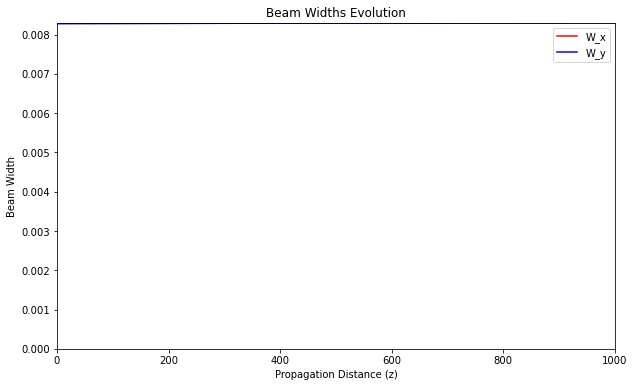

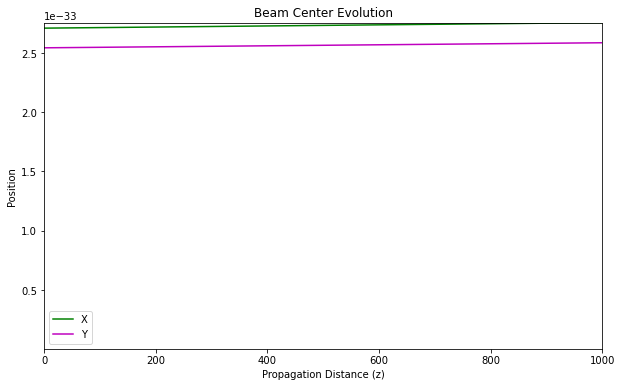

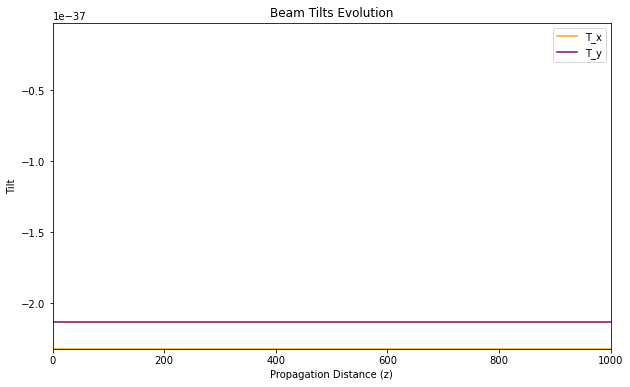

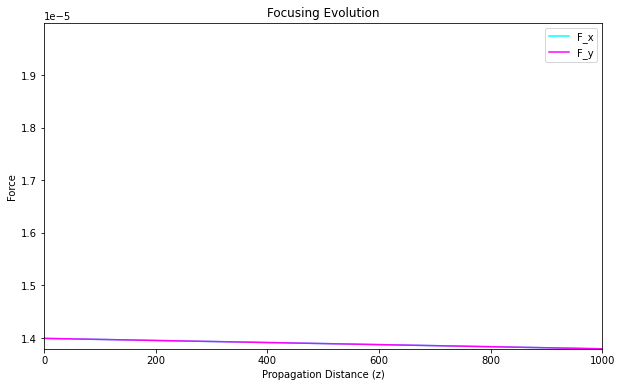

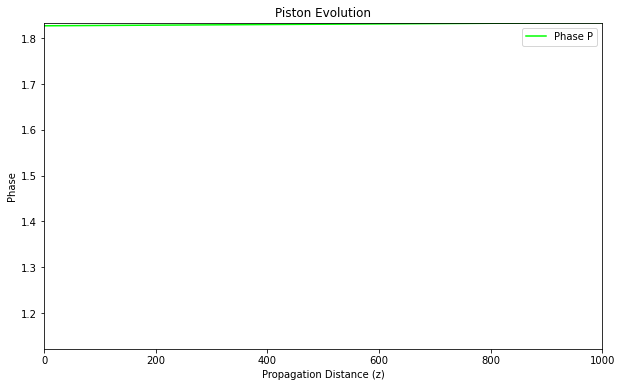

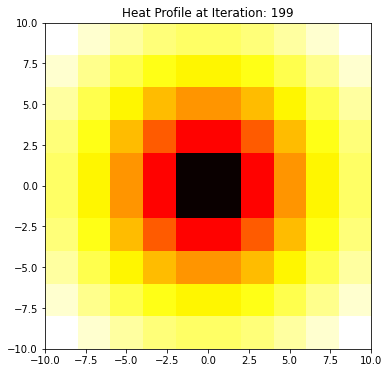

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Define setup for figures
def setup_figure(title, xlabel, ylabel, xlim, ylim):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    return fig, ax

# Define initialization and animation functions
def init_func(lines):
    for line in lines:
        line.set_data([], [])
    return lines

def animate_func(i, lines, z_values, data_indices, results):
    for line, idx in zip(lines, data_indices):
        if i < len(results) and results[i].shape[1] == len(z_values):
            line.set_data(z_values, results[i][idx, :])
    return lines

# Create animations for each parameter
def create_animation(title, x_label, y_label, xlim, ylim, line_styles, labels, data_indices, results):
    fig, ax = setup_figure(title, x_label, y_label, xlim, ylim)
    lines = [ax.plot([], [], style, label=label)[0] for style, label in zip(line_styles, labels)]
    ax.legend()
    ani = FuncAnimation(fig, animate_func, frames=len(results), fargs=(lines, np.linspace(*xlim, 100), data_indices, results),
                        init_func=lambda: init_func(lines), interval=150, blit=True)
    return ani

z_range = (0, 1000)
ylim_widths = (0, max([max(res[1,:]) for res in optical_results if res.shape[1] == 100] + [max(res[2,:]) for res in optical_results if res.shape[1] == 100]))
ylim_positions = (min([min(res[5,:]) for res in optical_results if res.shape[1] == 100] + [min(res[6,:]) for res in optical_results if res.shape[1] == 100]),
                  max([max(res[5,:]) for res in optical_results if res.shape[1] == 100] + [max(res[6,:]) for res in optical_results if res.shape[1] == 100]))
ylim_tilts = (min([min(res[3,:]) for res in optical_results if res.shape[1] == 100] + [min(res[4,:]) for res in optical_results if res.shape[1] == 100]),
              max([max(res[3,:]) for res in optical_results if res.shape[1] == 100] + [max(res[4,:]) for res in optical_results if res.shape[1] == 100]))

ani_widths = create_animation('Beam Widths Evolution', 'Propagation Distance (z)', 'Beam Width', z_range, ylim_widths, ['r-', 'b-'], ['W_x', 'W_y'], [1, 2], optical_results)
ani_positions = create_animation('Beam Center Evolution', 'Propagation Distance (z)', 'Position', z_range, ylim_positions, ['g-', 'm-'], ['X', 'Y'], [5, 6], optical_results)
ani_tilts = create_animation('Beam Tilts Evolution', 'Propagation Distance (z)', 'Tilt', z_range, ylim_tilts, ['orange', 'purple'], ['T_x', 'T_y'], [3, 4], optical_results)

# Display animations
display(HTML(ani_widths.to_jshtml()))
display(HTML(ani_positions.to_jshtml()))
display(HTML(ani_tilts.to_jshtml()))

# Additional setup for Forces and Phase
ylim_forces = (min([min(res[7,:]) for res in optical_results if res.shape[1] == 100] + [min(res[8,:]) for res in optical_results if res.shape[1] == 100]),
               max([max(res[7,:]) for res in optical_results if res.shape[1] == 100] + [max(res[8,:]) for res in optical_results if res.shape[1] == 100]))
ylim_phase = (min([min(res[9,:]) for res in optical_results if res.shape[1] == 100]), max([max(res[9,:]) for res in optical_results if res.shape[1] == 100]))

ani_forces = create_animation('Focusing Evolution', 'Propagation Distance (z)', 'Force', z_range, ylim_forces, ['cyan', 'magenta'], ['F_x', 'F_y'], [7, 8], optical_results)
ani_phase = create_animation('Piston Evolution', 'Propagation Distance (z)', 'Phase', z_range, ylim_phase, ['lime'], ['Phase P'], [9], optical_results)

# Display animations for Forces and Phase
display(HTML(ani_forces.to_jshtml()))
display(HTML(ani_phase.to_jshtml()))

def animate_heat(i, ax, thermal_results):
    ax.clear()  # Clear the previous frame
    if i < len(thermal_results):
        # Ensure there's data to display
        if thermal_results[i] is not None and np.any(thermal_results[i]):
            im = ax.imshow(thermal_results[i], cmap='hot', interpolation='nearest', extent=[-10, 10, -10, 10])
            ax.set_title('Heat Profile at Iteration: {}'.format(i))
        else:
            im = ax.imshow(np.zeros((10, 10)), cmap='hot', interpolation='nearest', extent=[-10, 10, -10, 10])
            ax.set_title('No data for Iteration: {}'.format(i))
    else:
        im = ax.imshow(np.zeros((10, 10)), cmap='hot', interpolation='nearest', extent=[-10, 10, -10, 10])
        ax.set_title('Iteration index out of range')
    return (im,)

# Checking if thermal_results has any data
if not thermal_results:
    print("No thermal data to display.")
else:
    fig_heat, ax_heat = plt.subplots(figsize=(8, 6))
    ani_heat = FuncAnimation(fig_heat, animate_heat, frames=len(thermal_results), fargs=(ax_heat, thermal_results), interval=150, blit=True)
    display(HTML(ani_heat.to_jshtml()))


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


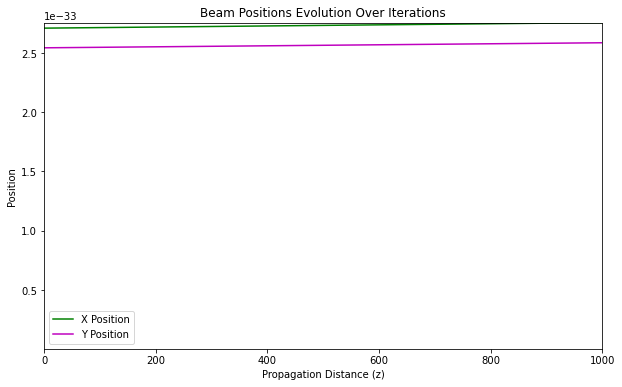

In [3]:
# Create figure for the Beam Positions animation
fig_positions, ax_positions = plt.subplots(figsize=(10, 6))
ax_positions.set_title('Beam Positions Evolution Over Iterations')
ax_positions.set_xlabel('Propagation Distance (z)')
ax_positions.set_ylabel('Position')
ax_positions.set_xlim(z_range[0], z_range[1])
ax_positions.set_ylim(min([np.min(data[5, :]) for data in optical_results] + [np.min(data[6, :]) for data in optical_results]), max([np.max(data[5, :]) for data in optical_results] + [np.max(data[6, :]) for data in optical_results]))

line3, = ax_positions.plot([], [], 'g-', label='X Position')
line4, = ax_positions.plot([], [], 'm-', label='Y Position')
ax_positions.legend()

# Initialization and animation functions
def init_positions():
    line3.set_data([], [])
    line4.set_data([], [])
    return line3, line4,

def animate_positions(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    X_values = optical_results[i][5, :]
    Y_values = optical_results[i][6, :]
    line3.set_data(z_values, X_values)
    line4.set_data(z_values, Y_values)
    return line3, line4,

# Create and display the animation for Beam Positions
ani_positions = FuncAnimation(fig_positions, animate_positions, init_func=init_positions, frames=len(optical_results), interval=150, blit=True)
HTML(ani_positions.to_jshtml())


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


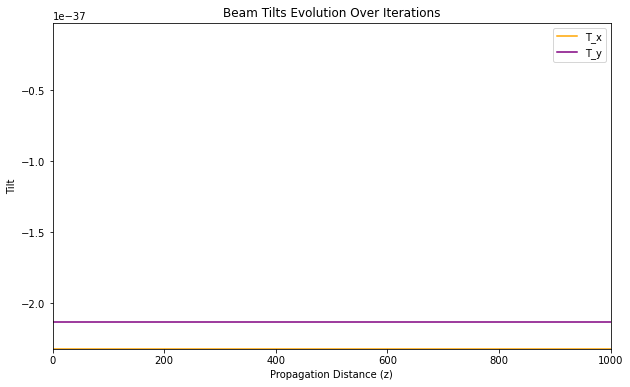

In [4]:
# Create figure for Beam Tilts animation
fig_tilts, ax_tilts = plt.subplots(figsize=(10, 6))
ax_tilts.set_title('Beam Tilts Evolution Over Iterations')
ax_tilts.set_xlabel('Propagation Distance (z)')
ax_tilts.set_ylabel('Tilt')
ax_tilts.set_xlim(z_range[0], z_range[1])
ax_tilts.set_ylim(min([np.min(data[3, :]) for data in optical_results] + [np.min(data[4, :]) for data in optical_results]), max([np.max(data[3, :]) for data in optical_results] + [np.max(data[4, :]) for data in optical_results]))

line5, = ax_tilts.plot([], [], 'orange', label='T_x')
line6, = ax_tilts.plot([], [], 'purple', label='T_y')
ax_tilts.legend()

def init_tilts():
    line5.set_data([], [])
    line6.set_data([], [])
    return line5, line6,

def animate_tilts(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    T_x_values = optical_results[i][3, :]
    T_y_values = optical_results[i][4, :]
    line5.set_data(z_values, T_x_values)
    line6.set_data(z_values, T_y_values)
    return line5, line6,

ani_tilts = FuncAnimation(fig_tilts, animate_tilts, init_func=init_tilts, frames=len(optical_results), interval=150, blit=True)
HTML(ani_tilts.to_jshtml())


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


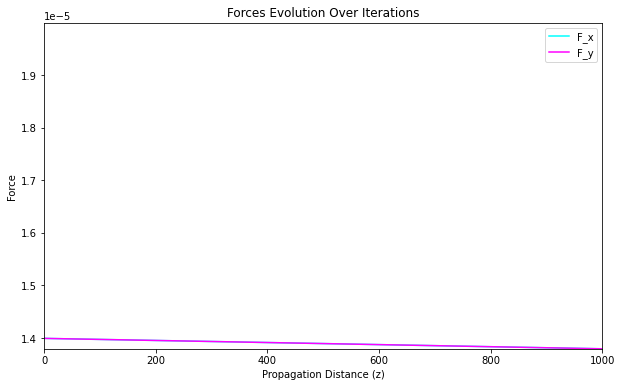

In [5]:
# Create figure for Forces animation
fig_forces, ax_forces = plt.subplots(figsize=(10, 6))
ax_forces.set_title('Forces Evolution Over Iterations')
ax_forces.set_xlabel('Propagation Distance (z)')
ax_forces.set_ylabel('Force')
ax_forces.set_xlim(z_range[0], z_range[1])
ax_forces.set_ylim(min([np.min(data[7, :]) for data in optical_results] + [np.min(data[8, :]) for data in optical_results]), max([np.max(data[7, :]) for data in optical_results] + [np.max(data[8, :]) for data in optical_results]))

line7, = ax_forces.plot([], [], 'cyan', label='F_x')
line8, = ax_forces.plot([], [], 'magenta', label='F_y')
ax_forces.legend()

def init_forces():
    line7.set_data([], [])
    line8.set_data([], [])
    return line7, line8,

def animate_forces(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    F_x_values = optical_results[i][7, :]
    F_y_values = optical_results[i][8, :]
    line7.set_data(z_values, F_x_values)
    line8.set_data(z_values, F_y_values)
    return line7, line8,

ani_forces = FuncAnimation(fig_forces, animate_forces, init_func=init_forces, frames=len(optical_results), interval=150, blit=True)
HTML(ani_forces.to_jshtml())


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


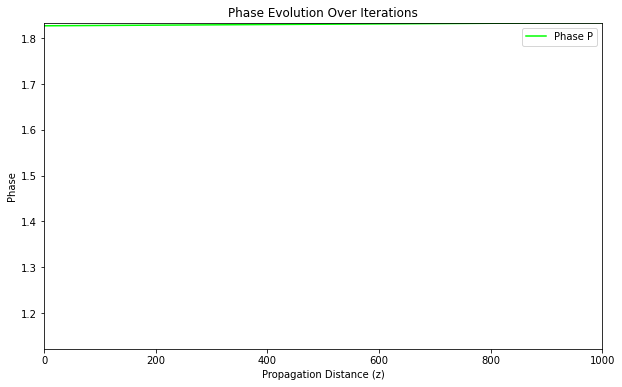

In [6]:
# Create figure for Phase animation
fig_phase, ax_phase = plt.subplots(figsize=(10, 6))
ax_phase.set_title('Phase Evolution Over Iterations')
ax_phase.set_xlabel('Propagation Distance (z)')
ax_phase.set_ylabel('Phase')
ax_phase.set_xlim(z_range[0], z_range[1])
ax_phase.set_ylim(min([np.min(data[9, :]) for data in optical_results]), max([np.max(data[9, :]) for data in optical_results]))

line9, = ax_phase.plot([], [], 'lime', label='Phase P')
ax_phase.legend()

def init_phase():
    line9.set_data([], [])
    return line9,

def animate_phase(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    P_values = optical_results[i][9, :]
    line9.set_data(z_values, P_values)
    return line9,

ani_phase = FuncAnimation(fig_phase, animate_phase, init_func=init_phase, frames=len(optical_results), interval=150, blit=True)
HTML(ani_phase.to_jshtml())


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


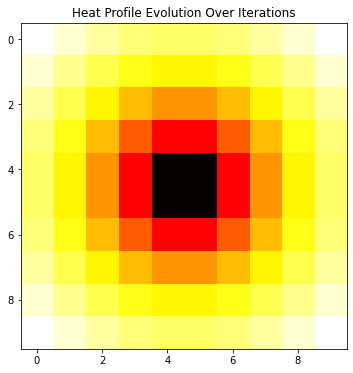

In [7]:
# Heat profile animation using the last axis
fig_heat, ax_heat = plt.subplots(figsize=(8, 6))
ax_heat.set_title('Heat Profile Evolution Over Iterations')
def animate_heat(i):
    ax_heat.imshow(thermal_results[i], cmap='hot', interpolation='nearest')
    return ax_heat,

ani_heat = FuncAnimation(fig_heat, animate_heat, frames=len(thermal_results), interval=150)
HTML(ani_heat.to_jshtml())
